# H-1B / LCA Disclosure Data Analysis — FY2026 Q1
**Source:** U.S. Department of Labor, Office of Foreign Labor Certification  
**Period:** October 1 – December 31, 2025

Three files share a common `CASE_NUMBER` key:
| File | Rows | Description |
|------|------|-------------|
| `LCA_Disclosure_Data_FY2026_Q1.xlsx` | ~1,042,437 | Main petition-level data (one row = one LCA application) |
| `LCA_Worksites_FY2026_Q1.xlsx` | ~124,998 | Per-worksite wage detail (up to 10 locations per case) |
| `LCA_Appendix_A_FY2026_Q1.xlsx` | ~101 | Master's-degree exemptions for H-1B-dependent/willful-violator employers |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = "dol_2026Q1/"
MAIN_FILE   = DATA_DIR + "LCA_Disclosure_Data_FY2026_Q1.xlsx"
SITES_FILE  = DATA_DIR + "LCA_Worksites_FY2026_Q1.xlsx"
APPXA_FILE  = DATA_DIR + "LCA_Appendix_A_FY2026_Q1.xlsx"

# Multiplier to annualise wages
UNIT_MULT = {'Year': 1, 'Month': 12, 'Bi-Weekly': 26, 'Week': 52, 'Hour': 2080}

---
## 1. File 1 — Main Disclosure Data
One row per LCA petition. Contains employer identity, job classification, wage offer, employment type, and visa class.

In [2]:
df = pd.read_excel(MAIN_FILE, engine='openpyxl')
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print("\nColumn list:")
for i, c in enumerate(df.columns, 1):
    print(f"  {i:>3}. {c}")

Rows: 83,120  |  Columns: 98

Column list:
    1. CASE_NUMBER
    2. CASE_STATUS
    3. RECEIVED_DATE
    4. DECISION_DATE
    5. ORIGINAL_CERT_DATE
    6. VISA_CLASS
    7. JOB_TITLE
    8. SOC_CODE
    9. SOC_TITLE
   10. FULL_TIME_POSITION
   11. BEGIN_DATE
   12. END_DATE
   13. TOTAL_WORKER_POSITIONS
   14. NEW_EMPLOYMENT
   15. CONTINUED_EMPLOYMENT
   16. CHANGE_PREVIOUS_EMPLOYMENT
   17. NEW_CONCURRENT_EMPLOYMENT
   18. CHANGE_EMPLOYER
   19. AMENDED_PETITION
   20. EMPLOYER_NAME
   21. TRADE_NAME_DBA
   22. EMPLOYER_ADDRESS1
   23. EMPLOYER_ADDRESS2
   24. EMPLOYER_CITY
   25. EMPLOYER_STATE
   26. EMPLOYER_POSTAL_CODE
   27. EMPLOYER_COUNTRY
   28. EMPLOYER_PROVINCE
   29. EMPLOYER_PHONE
   30. EMPLOYER_PHONE_EXT
   31. EMPLOYER_FEIN
   32. NAICS_CODE
   33. EMPLOYER_POC_LAST_NAME
   34. EMPLOYER_POC_FIRST_NAME
   35. EMPLOYER_POC_MIDDLE_NAME
   36. EMPLOYER_POC_JOB_TITLE
   37. EMPLOYER_POC_ADDRESS1
   38. EMPLOYER_POC_ADDRESS2
   39. EMPLOYER_POC_CITY
   40. EMPLOYER_POC_STA

In [3]:
# Key columns sample
KEY_COLS = [
    'CASE_NUMBER','CASE_STATUS','VISA_CLASS','RECEIVED_DATE','DECISION_DATE',
    'JOB_TITLE','SOC_CODE','SOC_TITLE','FULL_TIME_POSITION',
    'BEGIN_DATE','END_DATE','TOTAL_WORKER_POSITIONS',
    'NEW_EMPLOYMENT','CONTINUED_EMPLOYMENT','CHANGE_EMPLOYER',
    'EMPLOYER_NAME','EMPLOYER_STATE','NAICS_CODE',
    'WAGE_RATE_OF_PAY_FROM','WAGE_RATE_OF_PAY_TO','WAGE_UNIT_OF_PAY',
    'PREVAILING_WAGE','PW_UNIT_OF_PAY','PW_WAGE_LEVEL',
    'H_1B_DEPENDENT','WILLFUL_VIOLATOR'
]
df[KEY_COLS].head(5)

,CASE_NUMBER,CASE_STATUS,VISA_CLASS,RECEIVED_DATE,DECISION_DATE,JOB_TITLE,SOC_CODE,SOC_TITLE,FULL_TIME_POSITION,BEGIN_DATE,...,EMPLOYER_STATE,NAICS_CODE,WAGE_RATE_OF_PAY_FROM,WAGE_RATE_OF_PAY_TO,WAGE_UNIT_OF_PAY,PREVAILING_WAGE,PW_UNIT_OF_PAY,PW_WAGE_LEVEL,H_1B_DEPENDENT,WILLFUL_VIOLATOR
0,I-200-25356-504116,Certified - Withdrawn,H-1B,2025-12-22,2025-12-31,Instructor,25-1199.00,"Postsecondary Teachers, All Other",N,2026-01-03,...,FL,611310,37.85,NaN,Hour,27.97,Hour,I,No,No
1,I-200-25355-500286,Certified - Withdrawn,H-1B,2025-12-20,2025-12-31,AI/ML ENGINEER,15-1252.00,Software Developers,Y,2025-12-29,...,CA,54151,91500.00,NaN,Year,91291.00,Year,I,No,No
2,I-200-25351-491663,Certified - Withdrawn,H-1B,2025-12-17,2025-12-31,Research Scientist,19-1042.00,"Medical Scientists, Except Epidemiologists",Y,2026-02-01,...,TX,611310,58240.00,NaN,Year,45531.00,Year,I,No,No
3,I-200-25346-479299,Certified - Withdrawn,H-1B,2025-12-12,2025-12-31,IT Technical Associate (IT Service Management ...,15-1252.00,Software Developers,Y,2026-01-05,...,IL,611310,99383.00,NaN,Year,50447.00,Year,NaN,No,No
4,I-200-25325-428045,Certified - Withdrawn,H-1B,2025-11-21,2025-12-31,Propulsion System Diagnostic Validation Engineer,15-1252.00,Software Developers,Y,2025-12-08,...,MI,541511,55.00,NaN,Hour,49.13,Hour,II,Yes,No


In [4]:
print("VISA_CLASS breakdown:")
print(df['VISA_CLASS'].value_counts(), '\n')
print("CASE_STATUS breakdown:")
print(df['CASE_STATUS'].value_counts())

VISA_CLASS breakdown:
VISA_CLASS
H-1B               79852
E-3 Australian      2430
H-1B1 Chile          455
H-1B1 Singapore      383
Name: count, dtype: int64 

CASE_STATUS breakdown:
CASE_STATUS
Certified                74664
Certified - Withdrawn     6666
Withdrawn                 1398
Denied                     392
Name: count, dtype: int64


---
## 2. File 2 — Worksites Data
One row per physical worksite per case. Cases with multiple locations appear multiple times.  
Contains per-location wage and prevailing wage — useful for geographic salary analysis.

In [5]:
ws = pd.read_excel(SITES_FILE, engine='openpyxl')
print(f"Rows: {len(ws):,}  |  Columns: {ws.shape[1]}")
print("Columns:", list(ws.columns))
ws.head(5)

Rows: 124,998  |  Columns: 22
Columns: ['CASE_NUMBER', 'WORKSITE_WORKERS', 'SECONDARY_ENTITY', 'SECONDARY_ENTITY_BUSINESS_NAME', 'WORKSITE_ADDRESS1', 'WORKSITE_ADDRESS2', 'WORKSITE_CITY', 'WORKSITE_COUNTY', 'WORKSITE_STATE', 'WORKSITE_POSTAL_CODE', 'WAGE_RATE_OF_PAY_FROM', 'WAGE_RATE_OF_PAY_TO', 'WAGE_UNIT_OF_PAY', 'PREVAILING_WAGE', 'PW_UNIT_OF_PAY', 'PW_TRACKING_NUMBER', 'PW_WAGE_LEVEL', 'PW_OES_YEAR', 'PW_OTHER_SOURCE', 'PW_OTHER_YEAR', 'PW_SURVEY_PUBLISHER', 'PW_SURVEY_NAME']


,CASE_NUMBER,WORKSITE_WORKERS,SECONDARY_ENTITY,SECONDARY_ENTITY_BUSINESS_NAME,WORKSITE_ADDRESS1,WORKSITE_ADDRESS2,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE,...,WAGE_UNIT_OF_PAY,PREVAILING_WAGE,PW_UNIT_OF_PAY,PW_TRACKING_NUMBER,PW_WAGE_LEVEL,PW_OES_YEAR,PW_OTHER_SOURCE,PW_OTHER_YEAR,PW_SURVEY_PUBLISHER,PW_SURVEY_NAME
0,I-200-21004-993926,1.0,N,NaN,1725 Grismer Avenue,Apt. 208,Burbank,LOS ANGELES,CALIFORNIA,91504,...,Year,121160.0,Year,NaN,III,7/1/2020 - 6/30/2021,NaN,NaN,NaN,NaN
1,I-200-21004-993926,1.0,N,NaN,2950 North Hollywood Way,NaN,Burbank,LOS ANGELES,CALIFORNIA,91505,...,Year,121160.0,Year,NaN,III,7/1/2020 - 6/30/2021,NaN,NaN,NaN,NaN
2,I-200-21078-160290,1.0,N,NaN,450 NATIONAL AVENUE,NaN,MOUNTAIN VIEW,SANTA CLARA,CALIFORNIA,94043,...,Year,110469.0,Year,NaN,III,7/1/2020 - 6/30/2021,NaN,NaN,NaN,NaN
3,I-200-21078-160290,1.0,N,NaN,137 KNOCKASH HILL,NaN,SAN FRANCISCO,SAN FRANCISCO,CALIFORNIA,94127,...,Year,119101.0,Year,NaN,III,7/1/2020 - 6/30/2021,NaN,NaN,NaN,NaN
4,I-200-21102-216709,1.0,N,NaN,1890 FUMIA PLACE,NaN,SAN JOSE,SANTA CLARA,CALIFORNIA,95131,...,Year,120578.0,Year,NaN,II,7/1/2020 - 6/30/2021,NaN,NaN,NaN,NaN


In [6]:
# Cases with multiple worksites
multi = ws.groupby('CASE_NUMBER').size()
print(f"Unique cases in worksites file : {multi.nunique():,}")
print(f"Cases with >1 worksite         : {(multi > 1).sum():,}")
print(f"Max worksites for one case     : {multi.max()}")
print("\nWORKSITE_STATE top 10:")
print(ws['WORKSITE_STATE'].value_counts().head(10))

Unique cases in worksites file : 10
Cases with >1 worksite         : 34,923
Max worksites for one case     : 10

WORKSITE_STATE top 10:
WORKSITE_STATE
CALIFORNIA        23836
TEXAS             18652
NEW YORK           9135
WASHINGTON         8032
NEW JERSEY         7224
ILLINOIS           5270
NORTH CAROLINA     5266
GEORGIA            4780
MASSACHUSETTS      4289
FLORIDA            3826
Name: count, dtype: int64


---
## 3. File 3 — Appendix A
Only applies to H-1B **Dependent** or **Willful Violator** employers requesting a Master's-degree exemption.  
Very small file (101 rows). Not useful for financial analysis.

In [7]:
appxa = pd.read_excel(APPXA_FILE, engine='openpyxl')
print(f"Rows: {len(appxa):,}  |  Columns: {appxa.shape[1]}")
print("Columns:", list(appxa.columns))
appxa.head(10)

Rows: 101  |  Columns: 5
Columns: ['CASE_NUMBER', 'APPX_A_NO_OF_EXEMPT_WORKERS', 'APPX_A_NAME_OF_INSTITUTION', 'APPX_A_FIELD_OF_STUDY', 'APPX_A_DATE_OF_DEGREE']


,CASE_NUMBER,APPX_A_NO_OF_EXEMPT_WORKERS,APPX_A_NAME_OF_INSTITUTION,APPX_A_FIELD_OF_STUDY,APPX_A_DATE_OF_DEGREE
0,I-200-25356-502852,1,University of Illinois,Computer Science,2023-08-06
1,I-200-25353-497578,1,Regent University,Law - Human Rights,2023-05-05
2,I-200-25353-496333,1,Vinayaka Mission's Research Foundation,Master of Science,2011-07-06
3,I-200-25353-496317,1,Sardar Patel University,Master of Science,1999-12-14
4,I-200-25353-496272,1,OSMANIA UNIVERSITY,MASTER OF SCIENCE IN MATHEMATICS,2024-06-09
5,I-200-25346-480036,1,University of Minnesota,Education,2022-05-30
6,I-200-25346-479848,1,University of Wisconsin-Madison,Botany,2022-12-24
7,I-200-25346-479433,1,Carnegie Mellon University,Information Systems Management,2022-12-20
8,I-200-25346-479091,1,University of Central Florida,Computer Science,2022-12-15
9,I-200-25346-478973,1,Guru Nanak Dev University,Master of Science(Mathematics),2011-09-12


---
## 4. Employer Clustering & Top Companies
Normalise company names → aggregate petition count, headcount, and certified share.

In [8]:
df['EMPLOYER_NORM'] = df['EMPLOYER_NAME'].fillna('UNKNOWN').str.strip().str.upper()

# Annualise wages (cap extreme outliers at 99th pct for aggregation)
df['annual_wage'] = df['WAGE_RATE_OF_PAY_FROM'] * df['WAGE_UNIT_OF_PAY'].map(UNIT_MULT)
df['annual_pw']   = df['PREVAILING_WAGE']        * df['PW_UNIT_OF_PAY'].map(UNIT_MULT)
df['wage_premium_pct'] = (df['annual_wage'] - df['annual_pw']) / df['annual_pw'] * 100

grp = df.groupby('EMPLOYER_NORM').agg(
    petitions          = ('CASE_NUMBER',        'count'),
    total_workers      = ('TOTAL_WORKER_POSITIONS', 'sum'),
    new_hires          = ('NEW_EMPLOYMENT',      'sum'),
    renewals           = ('CONTINUED_EMPLOYMENT','sum'),
    certified          = ('CASE_STATUS',         lambda s: s.str.startswith('Certified').sum()),
    median_annual_wage = ('annual_wage',         'median'),
    median_pw          = ('annual_pw',           'median'),
    median_premium_pct = ('wage_premium_pct',    'median'),
).reset_index().sort_values('petitions', ascending=False).reset_index(drop=True)

grp['cert_rate_%'] = (grp['certified'] / grp['petitions'] * 100).round(1)
print(f"Unique normalised employers: {len(grp):,}")
grp.head(20)

Unique normalised employers: 17,986


,EMPLOYER_NORM,petitions,total_workers,new_hires,renewals,certified,median_annual_wage,median_pw,median_premium_pct,cert_rate_%
0,AMAZON.COM SERVICES LLC,2310,10616,712,5689,2310,158300.00,138476.0,11.201908,100.0
1,APPLE INC.,1638,1638,488,3,1637,175053.00,169859.0,0.000000,99.9
2,ERNST & YOUNG U.S. LLP,1622,1622,56,293,1599,169955.24,112424.0,36.389085,98.6
3,COGNIZANT TECHNOLOGY SOLUTIONS US CORP,1385,1385,2,86,1385,114795.00,114712.0,0.000000,100.0
4,MICROSOFT CORPORATION,1338,1338,110,709,1338,180710.00,149240.0,13.520214,100.0
5,"META PLATFORMS, INC",858,1098,34,26,857,222772.00,187574.0,15.974162,99.9
6,DELOITTE CONSULTING LLP,818,1688,22,203,817,149718.00,131939.0,0.000000,99.9
7,GOOGLE LLC,806,806,28,403,803,194569.50,175038.0,10.897614,99.6
8,TATA CONSULTANCY SERVICES LIMITED,785,785,0,404,780,91250.00,90854.0,0.000000,99.4
9,INFOSYS LIMITED,741,2281,1,12,736,94682.00,94682.0,0.000000,99.3


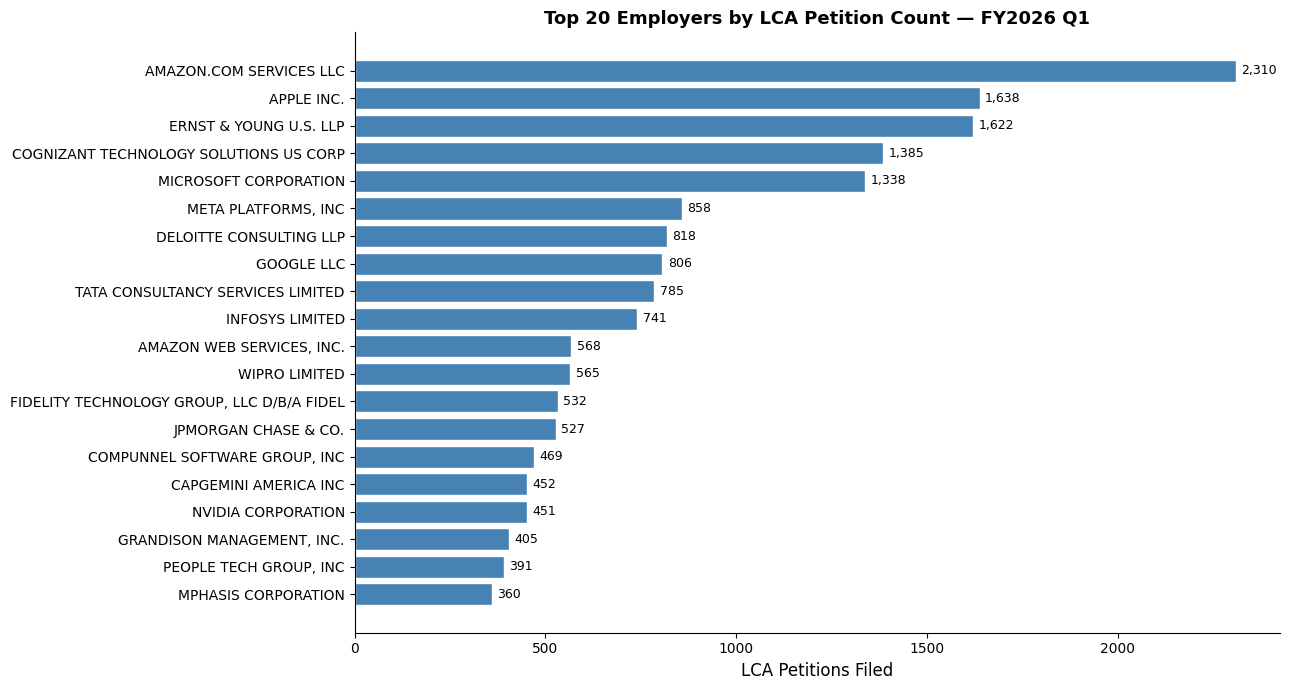

In [9]:
top20 = grp.head(20).copy()

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(top20['EMPLOYER_NORM'].str[:42], top20['petitions'], color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('LCA Petitions Filed', fontsize=12)
ax.set_title('Top 20 Employers by LCA Petition Count — FY2026 Q1', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('top20_employers.png', dpi=150)
plt.show()

---
## 5. Investment-Relevant Financial Signals

### 5a. Hiring Velocity — New Employment vs Renewals
`NEW_EMPLOYMENT = 1` means the company is adding net-new headcount (stronger growth signal than renewals).

In [10]:
# Publicly traded companies of interest (filter H-1B dependent staffing firms)
PUBLIC_COS = [
    'AMAZON.COM SERVICES LLC', 'AMAZON WEB SERVICES, INC.',
    'APPLE INC.',
    'MICROSOFT CORPORATION',
    'GOOGLE LLC',
    'META PLATFORMS, INC',
    'NVIDIA CORPORATION',
    'JPMORGAN CHASE & CO.',
    'ERNST & YOUNG U.S. LLP',
    'DELOITTE CONSULTING LLP',
    'FIDELITY TECHNOLOGY GROUP, LLC D/B/A FIDELITY INVESTMENTS',
]

pub = grp[grp['EMPLOYER_NORM'].isin(PUBLIC_COS)].copy()
pub['new_hire_rate_%'] = (pub['new_hires'] / pub['petitions'] * 100).round(1)
pub[['EMPLOYER_NORM','petitions','new_hires','renewals','new_hire_rate_%',
     'median_annual_wage','median_premium_pct','cert_rate_%']].sort_values('petitions', ascending=False)

,EMPLOYER_NORM,petitions,new_hires,renewals,new_hire_rate_%,median_annual_wage,median_premium_pct,cert_rate_%
0,AMAZON.COM SERVICES LLC,2310,712,5689,30.8,158300.00,11.201908,100.0
1,APPLE INC.,1638,488,3,29.8,175053.00,0.000000,99.9
2,ERNST & YOUNG U.S. LLP,1622,56,293,3.5,169955.24,36.389085,98.6
4,MICROSOFT CORPORATION,1338,110,709,8.2,180710.00,13.520214,100.0
5,"META PLATFORMS, INC",858,34,26,4.0,222772.00,15.974162,99.9
6,DELOITTE CONSULTING LLP,818,22,203,2.7,149718.00,0.000000,99.9
7,GOOGLE LLC,806,28,403,3.5,194569.50,10.897614,99.6
10,"AMAZON WEB SERVICES, INC.",568,168,1168,29.6,158000.00,13.754012,100.0
12,"FIDELITY TECHNOLOGY GROUP, LLC D/B/A FIDELITY ...",532,7,243,1.3,125119.00,0.000000,98.3
13,JPMORGAN CHASE & CO.,527,14,419,2.7,163400.00,14.460057,99.8


### 5b. Wage Premium Over Prevailing Wage
How much above the legally-required minimum a company offers — a proxy for talent competition intensity and compensation culture.

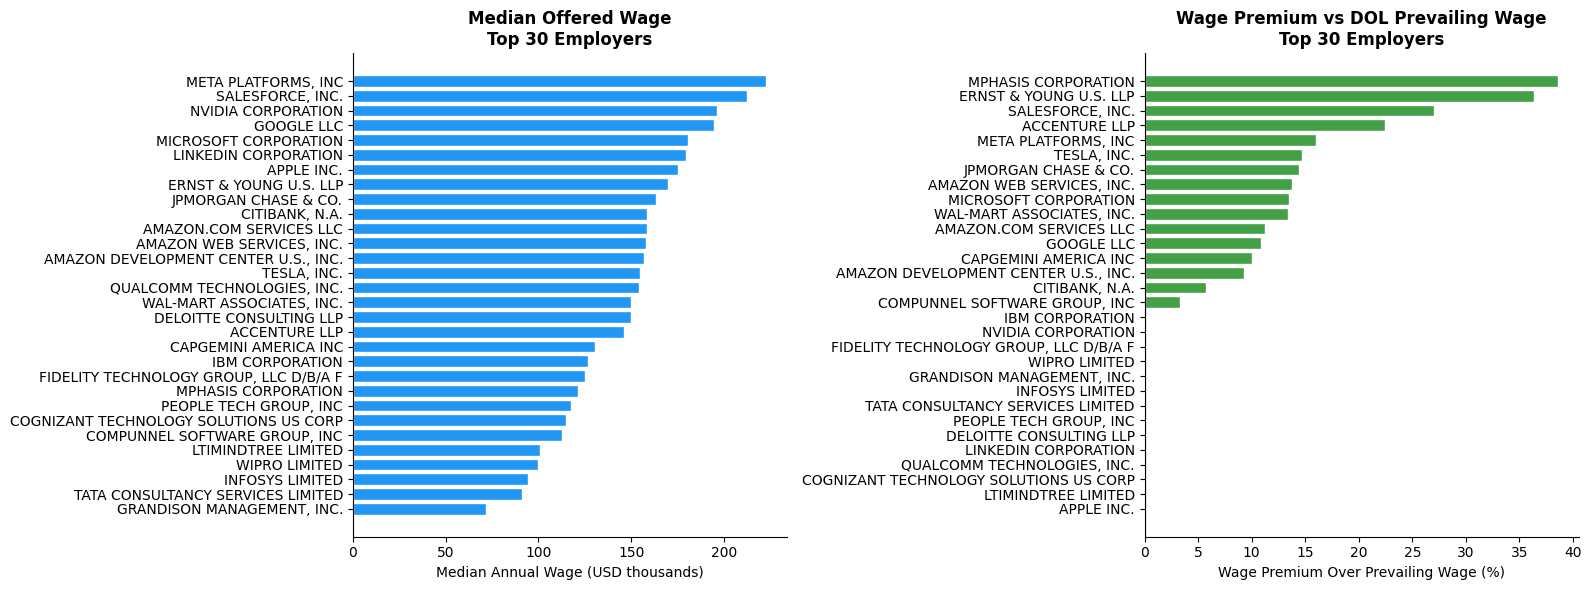

In [11]:
# Top 30 employers by petition count, exclude obvious staffing firms
top30 = grp.head(30).copy()
top30 = top30[top30['H_1B_DEPENDENT_pct'] < 80] if 'H_1B_DEPENDENT_pct' in top30.columns else top30
top30 = top30[top30['median_annual_wage'].notna() & (top30['median_annual_wage'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Median annual wage
ax = axes[0]
top30_sorted = top30.sort_values('median_annual_wage', ascending=True)
ax.barh(top30_sorted['EMPLOYER_NORM'].str[:38], top30_sorted['median_annual_wage'] / 1000,
        color='#2196F3', edgecolor='white')
ax.set_xlabel('Median Annual Wage (USD thousands)')
ax.set_title('Median Offered Wage\nTop 30 Employers', fontweight='bold')
ax.spines[['top','right']].set_visible(False)

# Wage premium
ax = axes[1]
top30_sorted2 = top30.sort_values('median_premium_pct', ascending=True)
colors = ['#E53935' if v < 0 else '#43A047' for v in top30_sorted2['median_premium_pct']]
ax.barh(top30_sorted2['EMPLOYER_NORM'].str[:38], top30_sorted2['median_premium_pct'],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Wage Premium Over Prevailing Wage (%)')
ax.set_title('Wage Premium vs DOL Prevailing Wage\nTop 30 Employers', fontweight='bold')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('wage_analysis.png', dpi=150)
plt.show()

### 5c. Wage Level Distribution — Seniority Composition
Level I = entry, II = experienced, III = senior, IV = fully competent specialist.  
Companies hiring mostly at Level III/IV indicate senior, high-cost headcount growth.

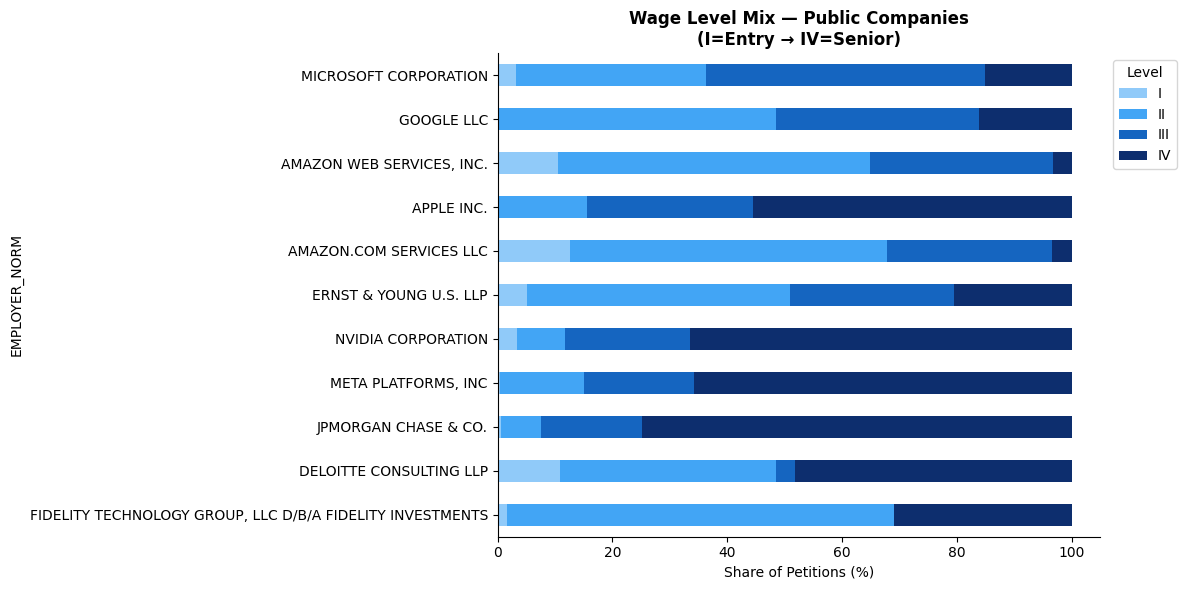

In [12]:
level_dist = (
    df[df['EMPLOYER_NORM'].isin(PUBLIC_COS)]
    .groupby(['EMPLOYER_NORM','PW_WAGE_LEVEL'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['I','II','III','IV'], fill_value=0)
)
level_dist_pct = level_dist.div(level_dist.sum(axis=1), axis=0) * 100

ax = level_dist_pct.sort_values('III', ascending=True).plot(
    kind='barh', stacked=True, figsize=(12, 6),
    color=['#90CAF9','#42A5F5','#1565C0','#0D2E6E']
)
ax.set_xlabel('Share of Petitions (%)')
ax.set_title('Wage Level Mix — Public Companies\n(I=Entry → IV=Senior)', fontweight='bold')
ax.legend(title='Level', bbox_to_anchor=(1.01, 1))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('wage_level_mix.png', dpi=150)
plt.show()

### 5d. SOC Role Breakdown — What Is Being Hired
Dominant SOC codes reveal if a company is ramping AI/ML, SWE, finance, or other capabilities.

In [13]:
soc_summary = (
    df.groupby(['SOC_CODE','SOC_TITLE'])
    .agg(petitions=('CASE_NUMBER','count'),
         median_wage=('annual_wage','median'))
    .reset_index()
    .sort_values('petitions', ascending=False)
    .head(20)
)
soc_summary

,SOC_CODE,SOC_TITLE,petitions,median_wage
147,15-1252.00,Software Developers,28081,143650.00
180,15-1299.08,Computer Systems Engineers/Architects,3132,110939.88
182,15-1299.09,Information Technology Project Managers,3085,137784.00
151,15-1253.00,Software Quality Assurance Analysts and Testers,3017,110000.00
195,15-2051.00,Data Scientists,2724,135904.00
15,11-3021.00,Computer and Information Systems Managers,2424,206487.00
141,15-1251.00,Computer Programmers,2020,98301.00
111,15-1211.00,Computer Systems Analysts,1756,110688.80
197,15-2051.01,Business Intelligence Analysts,1583,127000.00
251,17-2141.00,Mechanical Engineers,1328,110000.00


### 5e. Summary — Recommended Signals for Stock Correlation

| Signal | Column(s) | Investment Interpretation |
|--------|-----------|---------------------------|
| **Hiring velocity** | `NEW_EMPLOYMENT`, `TOTAL_WORKER_POSITIONS` | Leading indicator of revenue/product growth |
| **New vs renewal ratio** | `NEW_EMPLOYMENT / petitions` | Pure headcount expansion vs just visa maintenance |
| **Median offered wage** | `WAGE_RATE_OF_PAY_FROM` × unit | Compensation cost pressure; competitive talent demand |
| **Wage premium over PW** | `(wage - PREVAILING_WAGE) / PREVAILING_WAGE` | Willingness to overpay = talent scarcity or strong growth confidence |
| **Wage level mix** | `PW_WAGE_LEVEL` III+IV share | Senior-heavy hiring = capability ramp, not just headcount |
| **Certification rate** | `certified / petitions` | DOL approval health; willful-violator flag is a red flag |
| **SOC code mix** | `SOC_CODE` prefix `15-12xx` | Tech/software dominance signals product investment |
| **NAICS sector** | `NAICS_CODE` | Cross-industry hiring (e.g. bank hiring 541511 = fintech push) |

In [14]:
# Final summary table for publicly-traded employers
summary = (
    df[df['EMPLOYER_NORM'].isin(PUBLIC_COS)]
    .groupby('EMPLOYER_NORM')
    .agg(
        petitions          = ('CASE_NUMBER',              'count'),
        new_hires          = ('NEW_EMPLOYMENT',           'sum'),
        total_workers      = ('TOTAL_WORKER_POSITIONS',   'sum'),
        median_wage_k      = ('annual_wage',              lambda x: round(x.median() / 1000, 0)),
        median_premium_pct = ('wage_premium_pct',         lambda x: round(x.median(), 1)),
        senior_share_pct   = ('PW_WAGE_LEVEL',            lambda x: round((x.isin(['III','IV'])).mean() * 100, 1)),
        tech_role_pct      = ('SOC_CODE',                 lambda x: round(x.str.startswith('15-').mean() * 100, 1)),
    )
    .sort_values('petitions', ascending=False)
    .reset_index()
)
summary.columns = ['Company','Petitions','New Hires','Total Workers',
                   'Median Wage ($k)','Wage Premium (%)','Senior (III+IV) %','Tech Role %']
summary

,Company,Petitions,New Hires,Total Workers,Median Wage ($k),Wage Premium (%),Senior (III+IV) %,Tech Role %
0,AMAZON.COM SERVICES LLC,2310,712,10616,158.0,11.2,27.7,74.2
1,APPLE INC.,1638,488,1638,175.0,0.0,40.8,55.9
2,ERNST & YOUNG U.S. LLP,1622,56,1622,170.0,36.4,48.3,49.3
3,MICROSOFT CORPORATION,1338,110,1338,181.0,13.5,60.2,85.8
4,"META PLATFORMS, INC",858,34,1098,223.0,16.0,64.9,78.2
5,DELOITTE CONSULTING LLP,818,22,1688,150.0,0.0,42.9,81.9
6,GOOGLE LLC,806,28,806,195.0,10.9,40.9,80.1
7,"AMAZON WEB SERVICES, INC.",568,168,2899,158.0,13.8,31.7,91.2
8,"FIDELITY TECHNOLOGY GROUP, LLC D/B/A FIDELITY ...",532,7,532,125.0,0.0,18.8,99.6
9,JPMORGAN CHASE & CO.,527,14,527,163.0,14.5,57.9,86.0
